# Nonogram Solver — Demo

This notebook demonstrates solving the same 4×6 puzzle with both the classical brute-force solver and Grover's quantum algorithm.

All logic lives in the `nonogram` package; the notebook is purely for interactive exploration and result visualization.

## Setup

In [1]:
# ── Environment check ────────────────────────────────────────────────────────
# This notebook is designed to run inside the 'quantum-nonogram' conda env.
#
# First-time setup (run once from the project root):
#   make env      # creates .conda/ from environment.yml
#   make kernel   # registers 'Quantum Nonogram (Python 3.11)' in JupyterLab
#   make lab      # opens JupyterLab — select the kernel above
#
# If the imports below fail, your active kernel is wrong.
# Switch to: Kernel → Change Kernel → 'Quantum Nonogram (Python 3.11)'
# ─────────────────────────────────────────────────────────────────────────────
import sys, qiskit, nonogram

print(f"Python  : {sys.version.split()[0]}")
print(f"Qiskit  : {qiskit.__version__}")
print(f"nonogram: {nonogram.__file__}")


Python  : 3.11.15
Qiskit  : 2.3.0
nonogram: /Users/andrewpeterson/Projects/quantum-nonogram-solver/nonogram/__init__.py


In [2]:
import importlib.util, subprocess, sys

# Install the package if it isn't importable yet in this kernel session.
# Uses a regular (non-editable) install so the package lands directly in
# site-packages — importable immediately without a kernel restart.
# Developers who want live-reload can run `pip install -e .` once from the
# project root instead; this cell becomes a no-op in that case.
if importlib.util.find_spec("nonogram") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", ".."])
    importlib.invalidate_caches()

import nonogram, qiskit
print("nonogram:", nonogram.__file__)
print("Qiskit:  ", qiskit.__version__)


nonogram: /Users/andrewpeterson/Projects/quantum-nonogram-solver/nonogram/__init__.py
Qiskit:   2.3.0


## Puzzle Definition

```
      col:  (4) (1) (1) (1) (1) (4)
row (1,1):  ■  □  □  □  □  ■
row (2,2):  ■  ■  □  □  ■  ■
row(1,2,1): ■  □  ■  ■  □  ■
row (1,1):  ■  □  □  □  □  ■
```

Known solution bitstring (row-major): `100001110011101101100001`

In [3]:
from nonogram import display_nonogram

row_clues = [(1,), (0,)]
col_clues = [(1,), (0,)]
puzzle = (row_clues, col_clues)

EXPECTED = "1000"
num_solutions = 1

print("Expected solution:")
display_nonogram(EXPECTED, len(row_clues), len(col_clues))

Expected solution:
╔══╗
║■□║
║□□║
╚══╝


## Classical Solver

Brute-forces all 2²⁴ ≈ 16 M configurations. Profiled with `cProfile`.

> ⚠️ This cell takes ~18 minutes to complete.

In [4]:
import cProfile, pstats, io
from pstats import SortKey
from nonogram import classical_solve

pr = cProfile.Profile()
pr.enable()
classical_results = classical_solve(puzzle)
pr.disable()

s = io.StringIO()
pstats.Stats(pr, stream=s).sort_stats(SortKey.CUMULATIVE).print_stats(15)
print(s.getvalue())

         340 function calls in 0.000 seconds

   Ordered by: cumulative time
   List reduced from 35 to 15 due to restriction <15>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.000    0.000    0.000    0.000 /Users/andrewpeterson/Projects/quantum-nonogram-solver/.conda/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3665(run_code)
        2    0.000    0.000    0.000    0.000 {built-in method builtins.exec}
        1    0.000    0.000    0.000    0.000 /var/folders/9z/71vbg87x1bz3zp24ct89z8jc0000gn/T/ipykernel_81239/1548546556.py:1(<module>)
        1    0.000    0.000    0.000    0.000 /Users/andrewpeterson/Projects/quantum-nonogram-solver/nonogram/classical.py:4(classical_solve)
        1    0.000    0.000    0.000    0.000 /Users/andrewpeterson/Projects/quantum-nonogram-solver/nonogram/core.py:61(puzzle_to_boolean)
        2    0.000    0.000    0.000    0.000 /Users/andrewpeterson/Projects/quantum-nonogram-solver/.conda/lib/py

In [5]:
print(f"Classical solver found {len(classical_results)} solution(s):")
for sol in classical_results:
    print(sol)
    display_nonogram(sol, len(row_clues), len(col_clues))

Classical solver found 1 solution(s):
1000
╔══╗
║■□║
║□□║
╚══╝


## Quantum Solver (Grover's Algorithm)

Uses Qiskit's `PhaseOracleGate` and `Grover` (Qiskit ≥ 2.2, no extra dependencies).

In [6]:
from nonogram import quantum_solve

pr2 = cProfile.Profile()
pr2.enable()
quantum_results = quantum_solve(puzzle)
pr2.disable()

s2 = io.StringIO()
pstats.Stats(pr2, stream=s2).sort_stats(SortKey.CUMULATIVE).print_stats(15)
print(s2.getvalue())

         1950067 function calls (1913755 primitive calls) in 2.092 seconds

   Ordered by: cumulative time
   List reduced from 3092 to 15 due to restriction <15>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.000    0.000    2.095    1.048 /Users/andrewpeterson/Projects/quantum-nonogram-solver/.conda/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3665(run_code)
    992/2    0.043    0.000    2.095    1.048 {built-in method builtins.exec}
        1    0.000    0.000    2.095    2.095 /Users/andrewpeterson/Projects/quantum-nonogram-solver/nonogram/quantum.py:4(quantum_solve)
    770/2    0.005    0.000    2.062    1.031 <frozen importlib._bootstrap>:1165(_find_and_load)
    732/2    0.004    0.000    2.062    1.031 <frozen importlib._bootstrap>:1120(_find_and_load_unlocked)
    719/2    0.003    0.000    2.061    1.030 <frozen importlib._bootstrap>:666(_load_unlocked)
    633/2    0.002    0.000    2.060    1.030 <frozen importlib.

### Measurement Histogram

Matplotlib is building the font cache; this may take a moment.


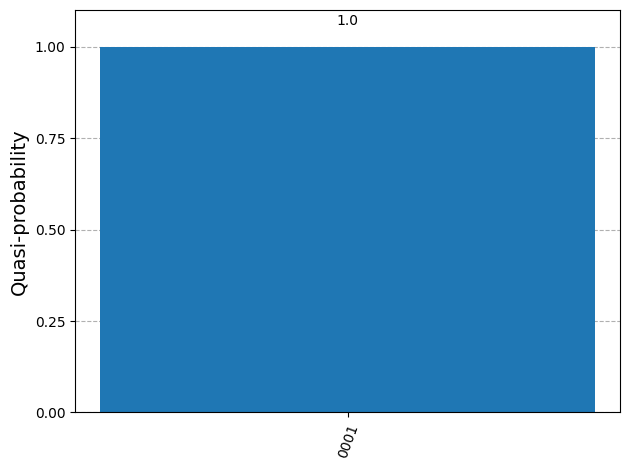

In [7]:
from operator import itemgetter
from qiskit.visualization import plot_histogram

top_results = dict(
    sorted(quantum_results.circuit_results[0].items(), key=itemgetter(1), reverse=True)[
        :num_solutions
    ]
)
display(plot_histogram(top_results))

### Quantum Solution Grid

In [8]:
print("Quantum solver found the following top result(s):")
for bitstring in top_results:
    sol = bitstring[::-1]  # Qiskit returns bits in reverse order
    print(sol)
    display_nonogram(sol, len(row_clues), len(col_clues))

Quantum solver found the following top result(s):
1000
╔══╗
║■□║
║□□║
╚══╝


---
## Benchmark Comparison

The `benchmark()` function runs both solvers on a puzzle and captures:

| Metric category | Classical | Quantum |
|---|---|---|
| Wall-clock solve time | ✓ | ✓ |
| Peak memory usage | ✓ | ✓ |
| Solutions found | ✓ | ✓ |
| Configurations evaluated | 2^(n·d) | — |
| Throughput (configs/s) | ✓ | — |
| Qubits | — | ✓ |
| Circuit depth | — | ✓ |
| Total / 2-qubit gate count | — | ✓ |
| Grover iterations | — | ✓ |
| Top-state measurement probability | — | ✓ |
| Theoretical Grover speedup √N | derived | derived |
| Actual speedup (time ratio) | derived | derived |
| Oracle call reduction | derived | derived |

> Use a **smaller puzzle** (e.g. 2×3) if you want interactive benchmarking;  
> the 4×6 puzzle takes ~18 min for the classical solver.

In [9]:
# Quick benchmark on a small puzzle (runs in seconds)
from nonogram import benchmark, print_report

small_puzzle = (
    [(1,), (1,), (1,)],   # 3 rows
    [(1,), (1,), (1,)],   # 3 cols  →  9 variables, 512 classical configs
)

report = benchmark(small_puzzle, run_classical=True, run_quantum=True)
print_report(report)


════════════════════════════════════════════════════════════════
  NONOGRAM SOLVER BENCHMARK  —  3×3 puzzle
════════════════════════════════════════════════════════════════

  Puzzle
  ────────────────────────────────────────────────────────────
  Variables (n×d)                                           9                             
  Search space (2^vars)                                   512                             
  Boolean expr length (chars)                             245                             

  Solver
  ────────────────────────────────────────────────────────────
                                                    Classical             Quantum (Grover)
  ────────────────────────────────────────────────────────────
  Solve time (s)                                     0.0477 s                     1.7298 s
  Peak memory (KB)                                     5.9 KB                   1,502.3 KB
  Solutions found                                           6          

In [ ]:
# Programmatic access to all metrics
c = report.classical
q = report.quantum

print("=== Classical ===")
print(f"  Solve time:           {c.solve_time_s:.4f} s")
print(f"  Throughput:           {c.configs_per_second:,.0f} configs/s")
print(f"  Peak memory:          {c.peak_memory_kb:.1f} KB")
print(f"  Solutions found:      {c.solutions_found}")

print("\n=== Quantum ===")
print(f"  Solve time:           {q.solve_time_s:.4f} s")
print(f"  Qubits:               {q.num_qubits}")
print(f"  Circuit depth:        {q.circuit_depth:,}")
print(f"  Total gates:          {q.total_gate_count:,}")
print(f"  2-qubit gates:        {q.two_qubit_gate_count:,}")
print(f"  Gate breakdown:       {q.gate_counts_by_type}")
print(f"  Grover iterations:    {q.grover_iterations}")
print(f"  Top-state prob:       {q.top_result_probability:.2%}")
print(f"  Oracle correct:       {q.oracle_evaluation_correct}")
print(f"  Peak memory:          {q.peak_memory_kb:.1f} KB")

print("\n=== Comparison ===")
print(f"  Search space:         2^{report.num_variables} = {report.search_space_size:,}")
print(f"  Theoretical speedup:  √{report.search_space_size} ≈ {report.theoretical_grover_speedup:,.1f}×")
print(f"  Actual speedup:       {report.actual_speedup:,.1f}×")
print(f"  Advantage ratio:      {report.quantum_advantage_ratio:.3f}")
print(f"  Oracle call reduction:{1 - q.grover_iterations / report.search_space_size:.1%}")

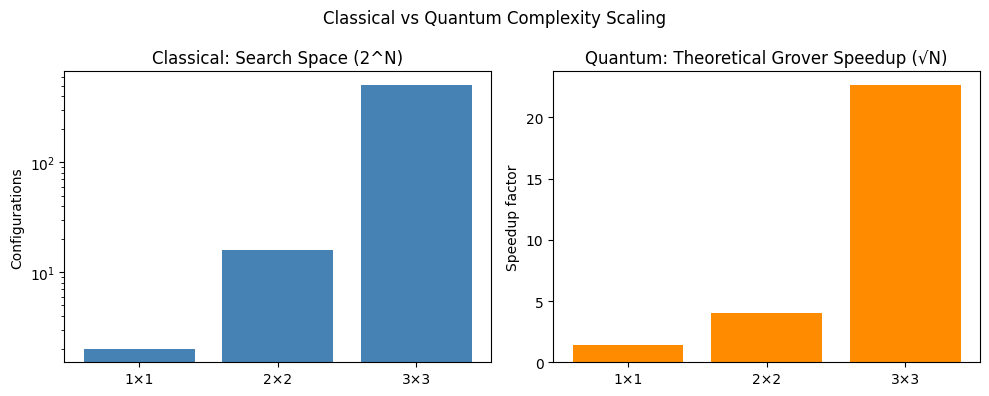

In [10]:
# Scaling study: show how quantum circuit resources grow with puzzle size
# (classical only — no quantum needed)
import matplotlib.pyplot as plt
from nonogram import benchmark

sizes = [
    ([(1,)],             [(1,)]),              # 1×1
    ([(1,), (1,)],       [(1,), (1,)]),        # 2×2
    ([(1,), (1,), (1,)], [(1,), (1,), (1,)]),  # 3×3
]
labels, search_spaces, theoretical_speedups = [], [], []
for rclues, cclues in sizes:
    r = benchmark((rclues, cclues), run_classical=False, run_quantum=False)
    labels.append(f"{r.rows}×{r.cols}")
    search_spaces.append(r.search_space_size)
    theoretical_speedups.append(r.theoretical_grover_speedup)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.bar(labels, search_spaces, color="steelblue")
ax1.set_title("Classical: Search Space (2^N)")
ax1.set_ylabel("Configurations")
ax1.set_yscale("log")

ax2.bar(labels, theoretical_speedups, color="darkorange")
ax2.set_title("Quantum: Theoretical Grover Speedup (√N)")
ax2.set_ylabel("Speedup factor")

plt.suptitle("Classical vs Quantum Complexity Scaling")
plt.tight_layout()
plt.show()